# 🎬 Amazon Prime — Notebook 1: Data Cleaning & Preprocessing

**Objective:** Load the raw dataset, understand its structure, handle missing values, and engineer new features for analysis.

**Dataset:** `amazon_prime_titles.csv` from [Kaggle](https://www.kaggle.com/datasets/shivamb/amazon-prime-movies-and-tv-shows)

---

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2️⃣ Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/amazon_prime_titles.csv')

print(f'📦 Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

📦 Dataset loaded: 9668 rows × 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local doctor to secure a lucrative bu...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Criminal threatening their stability...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, Richard Jones, Yancey Arias, No...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on him with a neighborhood kid he...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney Spears, Christina Aguilera, m...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her career to a new level in 2013 ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Costigan, Amanda Dickinson, Aliso...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famous but eccentric creature/spec...


## 3️⃣ Initial Inspection

In [3]:
# Dataset info
print('--- Dataset Info ---')
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [4]:
# Shape and data types
print(f'Shape: {df.shape}')
print('\nData Types:')
print(df.dtypes)

Shape: (9668, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [5]:
# Statistical summary
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,9668,9668,9668,7585,8435,672,155,9668.00,9331,9668,9668,9668
unique,9668,2,9668,5773,7927,86,84,NaN,24,219,518,9414
top,s1,Movie,The Grand Seduction,Mark Knight,Maggie Binkley,United States,"March 30, 2021",NaN,13+,1 Season,Drama,"Arpo was designed as a commando robot, built as a fierce fighting machine. B..."
freq,1,7814,1,113,56,253,14,NaN,2117,1342,986,15
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.34,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.92,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1920.00,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007.00,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.00,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.00,NaN,NaN,NaN,NaN


## 4️⃣ Missing Value Analysis

In [6]:
# Missing values count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('🔍 Missing Values Summary:')
print(missing)

🔍 Missing Values Summary:
            Missing Count  Missing %
date_added           9513      98.40
country              8996      93.05
director             2083      21.55
cast                 1233      12.75
rating                337       3.49


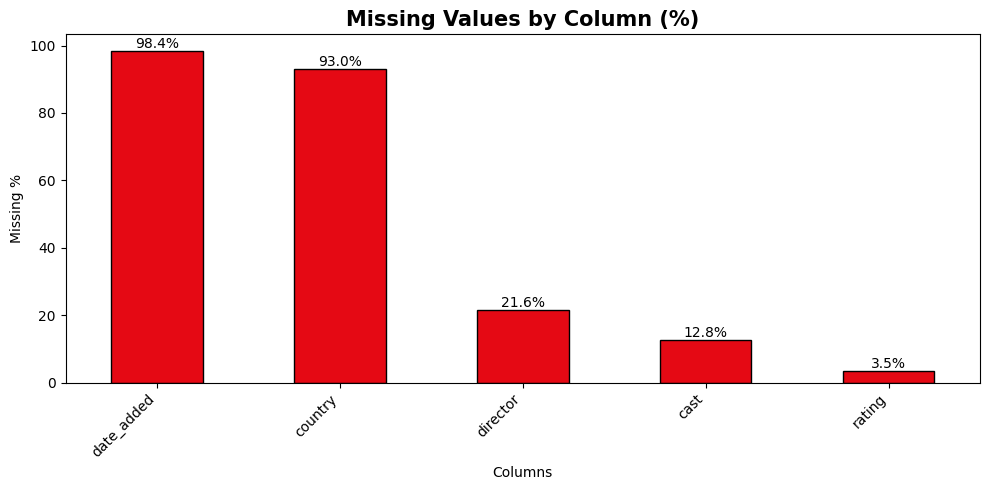

In [7]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing['Missing %'].plot(kind='bar', color='#E50914', edgecolor='black', ax=ax)
ax.set_title('Missing Values by Column (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Columns')
ax.set_ylabel('Missing %')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../visualizations/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Handle Missing Values

In [8]:
df_clean = df.copy()

# Fill categorical columns with 'Unknown'
fill_unknown = ['director', 'cast', 'country']
for col in fill_unknown:
    df_clean[col].fillna('Unknown', inplace=True)

# Fill rating with 'Not Rated'
df_clean['rating'].fillna('Not Rated', inplace=True)

# Drop rows where date_added or duration is missing (small %)
df_clean.dropna(subset=['date_added', 'duration'], inplace=True)

print(f'✅ After cleaning: {df_clean.shape[0]} rows remaining')
print(f'   Rows dropped: {df.shape[0] - df_clean.shape[0]}')

✅ After cleaning: 155 rows remaining
   Rows dropped: 9513


## 6️⃣ Data Type Conversions

In [9]:
# Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='mixed')

# Verify
print('date_added dtype:', df_clean['date_added'].dtype)
df_clean['date_added'].head()

date_added dtype: datetime64[ns]


0   2021-03-30
1   2021-03-30
2   2021-03-30
3   2021-03-30
4   2021-03-30
Name: date_added, dtype: datetime64[ns]

## 7️⃣ Feature Engineering

In [10]:
# Extract year and month from date_added
df_clean['year_added']  = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['month_name']  = df_clean['date_added'].dt.strftime('%B')

# Duration: separate movies (minutes) vs shows (seasons)
def extract_duration(row):
    try:
        return int(str(row['duration']).split()[0])
    except:
        return np.nan

df_clean['duration_int'] = df_clean.apply(extract_duration, axis=1)
df_clean['duration_unit'] = df_clean['duration'].str.extract(r'(\D+)')[0].str.strip()

# Decade of release
df_clean['decade'] = (df_clean['release_year'] // 10 * 10).astype(str) + 's'

# Primary genre (first genre listed)
df_clean['primary_genre'] = df_clean['listed_in'].str.split(',').str[0].str.strip()

# Primary country
df_clean['primary_country'] = df_clean['country'].str.split(',').str[0].str.strip()

print('✅ Feature engineering complete!')
print('New columns:', ['year_added','month_added','month_name','duration_int','duration_unit','decade','primary_genre','primary_country'])
df_clean[['title','type','year_added','month_name','duration_int','duration_unit','decade','primary_genre','primary_country']].head()

✅ Feature engineering complete!
New columns: ['year_added', 'month_added', 'month_name', 'duration_int', 'duration_unit', 'decade', 'primary_genre', 'primary_country']


,title,type,year_added,month_name,duration_int,duration_unit,decade,primary_genre,primary_country
0,The Grand Seduction,Movie,2021,March,113,min,2010s,Comedy,Canada
1,Take Care Good Night,Movie,2021,March,110,min,2010s,Drama,India
2,Secrets of Deception,Movie,2021,March,74,min,2010s,Action,United States
3,Pink: Staying True,Movie,2021,March,69,min,2010s,Documentary,United States
4,Monster Maker,Movie,2021,March,45,min,1980s,Drama,United Kingdom


## 8️⃣ Duplicate Check

In [11]:
duplicates = df_clean.duplicated(subset='show_id').sum()
print(f'🔁 Duplicate show_ids: {duplicates}')

title_dups = df_clean.duplicated(subset=['title', 'type']).sum()
print(f'🔁 Duplicate title+type combos: {title_dups}')

if title_dups > 0:
    df_clean.drop_duplicates(subset=['title', 'type'], keep='first', inplace=True)
    print(f'   Removed duplicates. Remaining rows: {df_clean.shape[0]}')

🔁 Duplicate show_ids: 0
🔁 Duplicate title+type combos: 0


## 9️⃣ Final Dataset Overview

In [12]:
print('=== FINAL CLEANED DATASET SUMMARY ===')
print(f'Total titles      : {len(df_clean)}')
print(f'Movies            : {len(df_clean[df_clean["type"]=="Movie"])}')
print(f'TV Shows          : {len(df_clean[df_clean["type"]=="TV Show"])}')
print(f'Date range added  : {df_clean["date_added"].min().date()} → {df_clean["date_added"].max().date()}')
print(f'Release year range: {int(df_clean["release_year"].min())} → {int(df_clean["release_year"].max())}')
print(f'Unique countries  : {df_clean["primary_country"].nunique()}')
print(f'Unique genres     : {df_clean["primary_genre"].nunique()}')
print(f'Remaining missing : {df_clean.isnull().sum().sum()}')

=== FINAL CLEANED DATASET SUMMARY ===
Total titles      : 155
Movies            : 16
TV Shows          : 139
Date range added  : 2021-03-30 → 2021-10-10
Release year range: 1967 → 2021
Unique countries  : 7
Unique genres     : 17
Remaining missing : 0


In [13]:
# Export cleaned dataset
df_clean.to_csv('../data/processed/amazon_prime_cleaned.csv', index=False)
print('✅ Cleaned dataset saved to data/processed/amazon_prime_cleaned.csv')

✅ Cleaned dataset saved to data/processed/amazon_prime_cleaned.csv
